# Credit Card Fraud Detection

**Goal:** predict which transactions are fraud (`Class = 1`) in a heavily imbalanced dataset.

We see only about 0.17% of transactions are fraud, so a model that says "not fraud" every time is ~99.8% accurate and completely useless. So we use precision, recall and PR-AUC instead of accuracy

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             average_precision_score, precision_recall_curve,
                             confusion_matrix)

RANDOM_STATE = 42

## 2. Load the data

In [2]:
df = pd.read_csv("creditcard.csv")
print("Shape:", df.shape)
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Explore
Columns: `Time` (seconds since first transaction), `V1`-`V28` (anonymised PCA features), `Amount`, and `Class` (1 = fraud).

In [3]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

counts = df["Class"].value_counts()
print("\nClass counts:\n", counts)
print("\nFraud percentage: {:.4f}%".format(100 * counts[1] / len(df)))

Missing values: 0
Duplicate rows: 1081

Class counts:
 Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.1727%


In [ ]:
# Remove exact duplicate rows as they add nothing and can leak between train and test
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print("Removed", before - len(df), "duplicate rows. New shape:", df.shape)
print("Fraud percentage now: {:.4f}%".format(100 * df["Class"].mean()))

Removed 1081 duplicate rows. New shape: (283726, 31)
Fraud percentage now: 0.1667%


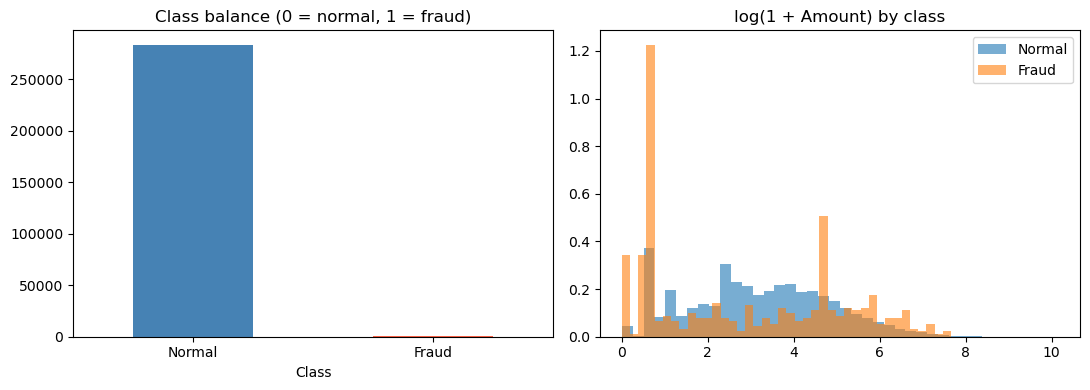

          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      283253.0   88.413575  250.379023  0.0  5.67  22.00   77.46  25691.16
1         473.0  123.871860  260.211041  0.0  1.00   9.82  105.89   2125.87


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df["Class"].value_counts().plot(kind="bar", ax=axes[0], color=["steelblue", "tomato"])
axes[0].set_title("Class balance (0 = normal, 1 = fraud)")
axes[0].set_xticklabels(["Normal", "Fraud"], rotation=0)

# log scale because Amount is very skewed
for label, name in [(0, "Normal"), (1, "Fraud")]:
    axes[1].hist(np.log1p(df.loc[df["Class"] == label, "Amount"]), bins=40, alpha=0.6, label=name, density=True)
axes[1].set_title("log(1 + Amount) by class")
axes[1].legend()
plt.tight_layout()
plt.show()

print(df.groupby("Class")["Amount"].describe())

**Observations**

The data is extremely imbalanced. Only 473 of 283,726 transactions (about 0.17%) are fraud, so accuracy alone can't tell a good model from a useless one.
Fraud amounts look different from normal ones. The median fraud amount is 9.82 against 22.00 for normal transactions, and a quarter of fraud transactions are 1.00 or less. Fraudsters seem to like small test-sized charges.
The averages are misleading. Fraud has a higher mean (123.87 vs 88.41), but that's pulled up by a few large transactions. The largest normal transaction is 25,691 and the largest fraud is 2,125, so the median is the better comparison

## 4. Split first, then scale
We split **before** doing anything else so the test set stays untouched and acts like new, unseen data. `stratify=y` keeps the same fraud ratio in train and test. The scaler is fitted on train only.

In [6]:
X = df.drop(columns="Class")
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
cols_to_scale = ["Amount", "Time"]
X_train = X_train.copy()
X_test = X_test.copy()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print("Train:", X_train.shape, "| fraud in train:", y_train.sum())
print("Test: ", X_test.shape,  "| fraud in test: ", y_test.sum())

Train: (226980, 30) | fraud in train: 378
Test:  (56746, 30) | fraud in test:  95


## 5. Helper to evaluate every model the same way

In [ ]:
results = []

def evaluate(name, y_true, y_pred, y_score):
    row = {
        "Model": name,
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "PR-AUC": average_precision_score(y_true, y_score),
    }
    results.append(row)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    print(f"{name}: precision={row['Precision']:.3f} recall={row['Recall']:.3f} "
          f"F1={row['F1']:.3f} PR-AUC={row['PR-AUC']:.3f}")
    print(f"   caught fraud: {tp}, missed fraud: {fn}, false alarms: {fp}")
    return row

scores = {}  # stores probability scores for later curves

## 6. Baseline: plain logistic regression 
We see accuracy would look great here but recall on fraud is weak.

In [8]:
lr_plain = LogisticRegression(max_iter=1000)
lr_plain.fit(X_train, y_train)
p = lr_plain.predict_proba(X_test)[:, 1]
scores["LogReg (plain)"] = p
print("Accuracy (misleading!):", (lr_plain.predict(X_test) == y_test).mean())
evaluate("LogReg (plain)", y_test, (p >= 0.5).astype(int), p)

Accuracy (misleading!): 0.9991365030134283
LogReg (plain): precision=0.848 recall=0.589 F1=0.696 PR-AUC=0.692
   caught fraud: 56, missed fraud: 39, false alarms: 10


{'Model': 'LogReg (plain)',
 'Precision': 0.8484848484848485,
 'Recall': 0.5894736842105263,
 'F1': 0.6956521739130435,
 'PR-AUC': 0.6923283275024147}

## 7. Logistic regression with class weights

In [9]:
lr_bal = LogisticRegression(max_iter=1000, class_weight="balanced")
lr_bal.fit(X_train, y_train)
p = lr_bal.predict_proba(X_test)[:, 1]
scores["LogReg (balanced)"] = p
evaluate("LogReg (balanced)", y_test, (p >= 0.5).astype(int), p)

LogReg (balanced): precision=0.056 recall=0.874 F1=0.106 PR-AUC=0.672
   caught fraud: 83, missed fraud: 12, false alarms: 1393


{'Model': 'LogReg (balanced)',
 'Precision': 0.05623306233062331,
 'Recall': 0.8736842105263158,
 'F1': 0.10566518141311267,
 'PR-AUC': 0.6719353631354262}

## 8. Random forest

In [10]:
rf = RandomForestClassifier(
    n_estimators=100, max_depth=12, class_weight="balanced_subsample",
    n_jobs=-1, random_state=RANDOM_STATE
)
rf.fit(X_train, y_train)
p = rf.predict_proba(X_test)[:, 1]
scores["Random Forest"] = p
evaluate("Random Forest", y_test, (p >= 0.5).astype(int), p)

Random Forest: precision=0.885 recall=0.726 F1=0.798 PR-AUC=0.795
   caught fraud: 69, missed fraud: 26, false alarms: 9


{'Model': 'Random Forest',
 'Precision': 0.8846153846153846,
 'Recall': 0.7263157894736842,
 'F1': 0.7976878612716763,
 'PR-AUC': 0.7953313055681281}

## 9. Gradient boosting 

In [11]:
hgb = HistGradientBoostingClassifier(random_state=RANDOM_STATE)
w = compute_sample_weight("balanced", y_train)
hgb.fit(X_train, y_train, sample_weight=w)
p = hgb.predict_proba(X_test)[:, 1]
scores["Gradient Boosting"] = p
evaluate("Gradient Boosting", y_test, (p >= 0.5).astype(int), p)

c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

Gradient Boosting: precision=0.369 recall=0.832 F1=0.511 PR-AUC=0.729
   caught fraud: 79, missed fraud: 16, false alarms: 135


{'Model': 'Gradient Boosting',
 'Precision': 0.3691588785046729,
 'Recall': 0.8315789473684211,
 'F1': 0.511326860841424,
 'PR-AUC': 0.7292505337138767}

## 10. SMOTE
SMOTE creates synthetic fraud examples in the training set only.

In [18]:
!pip install imbalanced-learn


   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]




[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: c:\Users\DS-31\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [19]:
try:
    from imblearn.over_sampling import SMOTE
    sm = SMOTE(random_state=RANDOM_STATE)
    X_res, y_res = sm.fit_resample(X_train, y_train)
    print("After SMOTE, train class counts:", np.bincount(y_res))

    lr_smote = LogisticRegression(max_iter=1000)
    lr_smote.fit(X_res, y_res)
    p = lr_smote.predict_proba(X_test)[:, 1]
    scores["LogReg + SMOTE"] = p
    evaluate("LogReg + SMOTE", y_test, (p >= 0.5).astype(int), p)
except ImportError:
    print("imbalanced-learn not installed, skipping SMOTE.")

After SMOTE, train class counts: [226602 226602]
LogReg + SMOTE: precision=0.053 recall=0.874 F1=0.100 PR-AUC=0.677
   caught fraud: 83, missed fraud: 12, false alarms: 1482


## 11. Results table

In [13]:
res_df = pd.DataFrame(results).set_index("Model").round(3)
res_df.sort_values("PR-AUC", ascending=False)

,Precision,Recall,F1,PR-AUC
Model,,,,
Random Forest,0.885,0.726,0.798,0.795
Gradient Boosting,0.369,0.832,0.511,0.729
LogReg (plain),0.848,0.589,0.696,0.692
LogReg + SMOTE,0.053,0.874,0.100,0.677
LogReg (balanced),0.056,0.874,0.106,0.672


## 12. Precision-recall curves

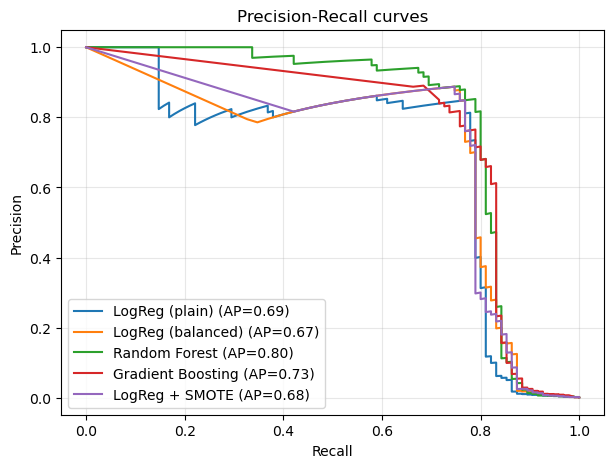

In [14]:
plt.figure(figsize=(7, 5))
for name, p in scores.items():
    prec, rec, _ = precision_recall_curve(y_test, p)
    plt.plot(rec, prec, label=f"{name} (AP={average_precision_score(y_test, p):.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curves")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 13. Threshold tuning on the best model
The default cutoff is 0.5 . A higher cutoff means fewer false alarms but more missed fraud; a lower one catches more fraud but annoys more customers.



In [15]:
best_name = res_df["PR-AUC"].idxmax()
print("Best model by PR-AUC:", best_name)
best_scores = scores[best_name]

rows = []
for t in [0.1, 0.2, 0.3, 0.5, 0.7, 0.9]:
    pred = (best_scores >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    rows.append({
        "Threshold": t,
        "Precision": round(precision_score(y_test, pred, zero_division=0), 3),
        "Recall": round(recall_score(y_test, pred), 3),
        "Fraud caught": tp, "Fraud missed": fn, "False alarms": fp,
    })
pd.DataFrame(rows)

Best model by PR-AUC: Random Forest


,Threshold,Precision,Recall,Fraud caught,Fraud missed,False alarms
0,0.1,0.328,0.832,79,16,162
1,0.2,0.631,0.811,77,18,45
2,0.3,0.824,0.789,75,20,16
3,0.5,0.885,0.726,69,26,9
4,0.7,0.915,0.684,65,30,6
5,0.9,0.960,0.505,48,47,2


Chosen threshold: 0.3
Missing a fraud usually costs a bank more than checking a normal transaction, so I preferred a threshold lower than the default 0.5. Going from 0.5 to 0.3 catches 6 more fraud cases (75 instead of 69) for only 7 more false alarms (16 instead of 9). Going lower to 0.2 gets just 2 more fraud cases but adds 29 more false alarms (45 total) and drops precision to 0.63, which isn't worth it. At 0.3, precision is still 0.82 and recall is 0.79. A different bank might choose differently depending on how much a review costs compared to a missed fraud.
Note: I checked thresholds on the test set. A stricter version would pick the threshold on a separate validation set.

## 14. Which features mattered? (Random Forest)
The V1-V28 columns are anonymised, so we can see *which* matter but not *why*. That is a real limitation of this dataset.

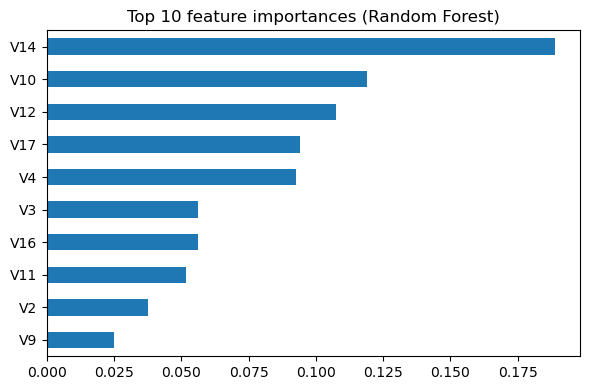

V14    0.188763
V10    0.119161
V12    0.107470
V17    0.094053
V4     0.092682
V3     0.056328
V16    0.056147
V11    0.051652
V2     0.037495
V9     0.025090
dtype: float64

In [16]:
imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)
imp.sort_values().plot(kind="barh", figsize=(6, 4), title="Top 10 feature importances (Random Forest)")
plt.tight_layout()
plt.show()
imp

#### Final Summary

In [17]:
print("=== SUMMARY ===")
print("Rows after removing duplicates:", len(df))
print("Fraud rate: {:.4f}%".format(100 * df["Class"].mean()))
print("Fraud cases in test set:", int(y_test.sum()))
print()
print(res_df.sort_values("PR-AUC", ascending=False).to_string())
print()
print("Best model:", best_name)
print(pd.DataFrame(rows).to_string(index=False))
print()
print("Top 5 features:", list(imp.index[:5]))

=== SUMMARY ===
Rows after removing duplicates: 283726
Fraud rate: 0.1667%
Fraud cases in test set: 95

                   Precision  Recall     F1  PR-AUC
Model                                              
Random Forest          0.885   0.726  0.798   0.795
Gradient Boosting      0.369   0.832  0.511   0.729
LogReg (plain)         0.848   0.589  0.696   0.692
LogReg + SMOTE         0.053   0.874  0.100   0.677
LogReg (balanced)      0.056   0.874  0.106   0.672

Best model: Random Forest
 Threshold  Precision  Recall  Fraud caught  Fraud missed  False alarms
       0.1      0.328   0.832            79            16           162
       0.2      0.631   0.811            77            18            45
       0.3      0.824   0.789            75            20            16
       0.5      0.885   0.726            69            26             9
       0.7      0.915   0.684            65            30             6
       0.9      0.960   0.505            48            47             2

